<a href="https://colab.research.google.com/github/safiraroha26/latihan1-html/blob/main/safira_noise_monitoring-ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA LOADING

import library


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)

load dataset dari data sensor noise

In [ ]:
# Memuat data dengan separator yang sesuai
df = pd.read_csv('noise_features.csv', sep=';')

# Exploratory Data Analysis

In [ ]:
print("\nExploratory Data Analysis")

#cek info kolom dan tipe data
print(df.info())

#statistik deskriptif
print(df.describe())

#target kondisi
print(df['kondisi'].value_counts())

#cek missing values
print("Jumlah data kosong:\n", df.isnull().sum())


Exploratory Data Analysis
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          561 non-null    int64  
 1   waktu_awal  561 non-null    object 
 2   avg_nilai   561 non-null    float64
 3   max_nilai   561 non-null    int64  
 4   min_nilai   561 non-null    int64  
 5   kondisi     561 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 26.4+ KB
None
               id   avg_nilai   max_nilai   min_nilai
count  561.000000  561.000000  561.000000  561.000000
mean   281.000000   23.824483   52.365419   14.450980
std    162.091024   14.638937  112.747237    1.533496
min      1.000000   15.000000   15.000000    4.000000
25%    141.000000   20.294100   22.000000   14.000000
50%    281.000000   20.777800   22.000000   15.000000
75%    421.000000   21.166700   24.000000   15.000000
max    561.000000  195.200000  766.000000

# Data Cleaning dan Preprocesing


menentukan fitur x dan target y


In [ ]:
# Define X (features) and y (target) from the DataFrame 'df'
X = df[['avg_nilai', 'max_nilai', 'min_nilai']] # Sesuaikan kolom fitur kamu
y = df['kondisi']

# Encode target 'kondisi' (misal: sepi 1, sedang 1, ramai 2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

standardization

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nStandardization Berhasil: Data sekarang memiliki rata-rata 0 dan standar deviasi 1.")


Standardization Berhasil: Data sekarang memiliki rata-rata 0 dan standar deviasi 1.


# Splitting Data


In [ ]:
# Membagi data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y_encoded
)

# Ambil data asli untuk plotting nanti (agar sumbu x & y bukan nilai hasil scaling)
_, X_test_plot, _, _ = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Data Training: {X_train.shape[0]} baris")
print(f"Data Testing: {X_test.shape[0]} baris")

Data Training: 448 baris
Data Testing: 113 baris


# Modelling

In [ ]:
# Inisialisasi Model
model_gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
model_svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)


# Evaluation

proses yang dilakukan widget "Test and Score" di Orange

In [ ]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# mendapatkan prediksi Cross Validation untuk Confusion Matrix
pred_gb_cv = cross_val_predict(model_gb, X_scaled, y_encoded, cv=cv)
pred_svm_cv = cross_val_predict(model_svm, X_scaled, y_encoded, cv=cv)

print(f"\nAkurasi GB (10-Fold CV): {accuracy_score(y_encoded, pred_gb_cv):.4f}")
print(f"Akurasi SVM (10-Fold CV): {accuracy_score(y_encoded, pred_svm_cv):.4f}")


Akurasi GB (10-Fold CV): 0.9982
Akurasi SVM (10-Fold CV): 0.8253


evaluasi confusion matrix

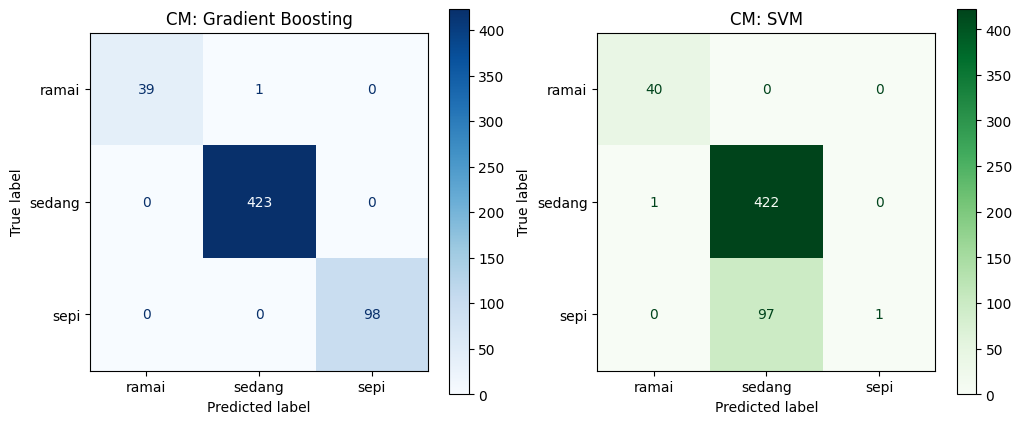

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_encoded, pred_gb_cv,
                                        display_labels=le.classes_,
                                        ax=ax[0], cmap='Blues')
ax[0].set_title("CM: Gradient Boosting")

ConfusionMatrixDisplay.from_predictions(y_encoded, pred_svm_cv,
                                        display_labels=le.classes_,
                                        ax=ax[1], cmap='Greens')
ax[1].set_title("CM: SVM")
plt.show()

# Visualisasi

menggunakan scatter plot, dengan x: avg_nilai, y: max_nilai

In [ ]:
plt.figure(figsize=(14, 6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

visualisasi prediksi gradient boosting

Text(0.5, 1.0, 'Scatter Plot: Prediksi GB (avg vs max)')

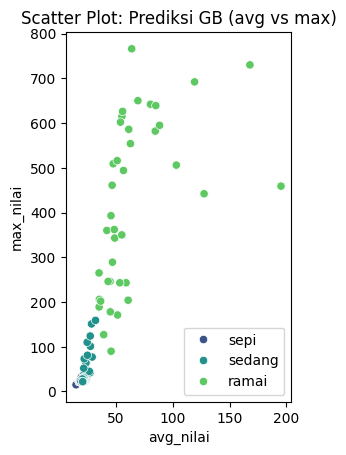

In [ ]:
plt.subplot(1, 2, 1)
sns.scatterplot(x=df['avg_nilai'], y=df['max_nilai'],
                hue=le.inverse_transform(pred_gb_cv), palette='viridis')
plt.title("Scatter Plot: Prediksi GB (avg vs max)")

visualisasi hasil prediksi svm

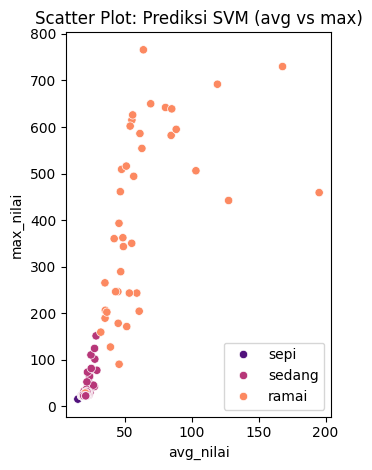

In [ ]:
plt.subplot(1, 2, 2)
sns.scatterplot(x=df['avg_nilai'], y=df['max_nilai'],
                hue=le.inverse_transform(pred_svm_cv), palette='magma')
plt.title("Scatter Plot: Prediksi SVM (avg vs max)")

plt.tight_layout()
plt.show()

# Prediction (Tabel Hasil Akhir)

sepeerti data table di orange


In [ ]:
df_prediksi = df.copy()
df_prediksi['Prediksi_GB'] = le.inverse_transform(pred_gb_cv)
df_prediksi['Prediksi_SVM'] = le.inverse_transform(pred_svm_cv)

print("\nTabel Hasil Prediksi Akhir")
print(df_prediksi[['waktu_awal', 'avg_nilai', 'max_nilai', 'kondisi', 'Prediksi_GB', 'Prediksi_SVM']].head(10))


Tabel Hasil Prediksi Akhir
            waktu_awal  avg_nilai  max_nilai kondisi Prediksi_GB Prediksi_SVM
0  2026-04-26 06:54:00    15.0000         15    sepi        sepi         sepi
1  2026-04-26 06:55:00    24.0000         29  sedang      sedang       sedang
2  2026-04-26 06:56:00    21.6667         26  sedang      sedang       sedang
3  2026-04-26 06:57:00    21.8000         22  sedang      sedang       sedang
4  2026-04-26 06:58:00    20.6667         22  sedang      sedang       sedang
5  2026-04-26 06:59:00    21.6000         24  sedang      sedang       sedang
6  2026-04-26 07:00:00    20.5000         24  sedang      sedang       sedang
7  2026-04-26 07:01:00    20.4000         22  sedang      sedang       sedang
8  2026-04-26 07:02:00    19.0000         22    sepi        sepi       sedang
9  2026-04-26 07:03:00    19.6667         22    sepi        sepi       sedang
